<a href="https://colab.research.google.com/github/AbhinavDharam/Netflix-Content-Strategy-Viewer-Preference-Analysis/blob/main/Country_and_Duration_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_netflix_data.csv to cleaned_netflix_data.csv


In [ ]:
df = pd.read_csv('cleaned_netflix_data.csv')

In [ ]:
df['country_list'] = df['country'].apply(lambda x: [i.strip() for i in x.split(',')] if x != 'Unknown' else [])

In [ ]:
country_df = df.explode('country_list')
country_df = country_df[country_df['country_list'].notna()]
country_df = country_df[country_df['country_list'] != '']

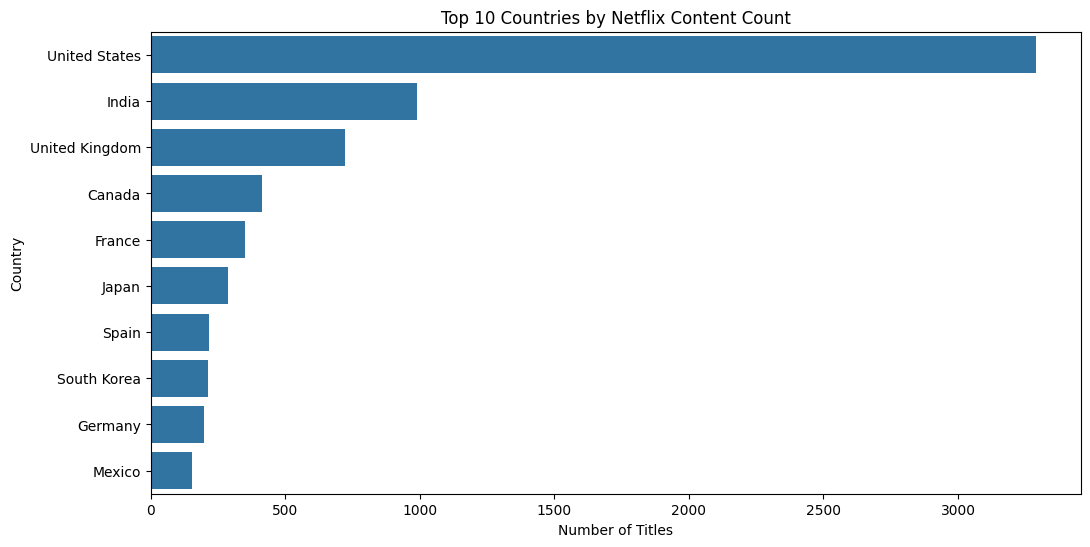

In [ ]:
#Top countries producing netflix content
top_countries = country_df['country_list'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Netflix Content Count")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

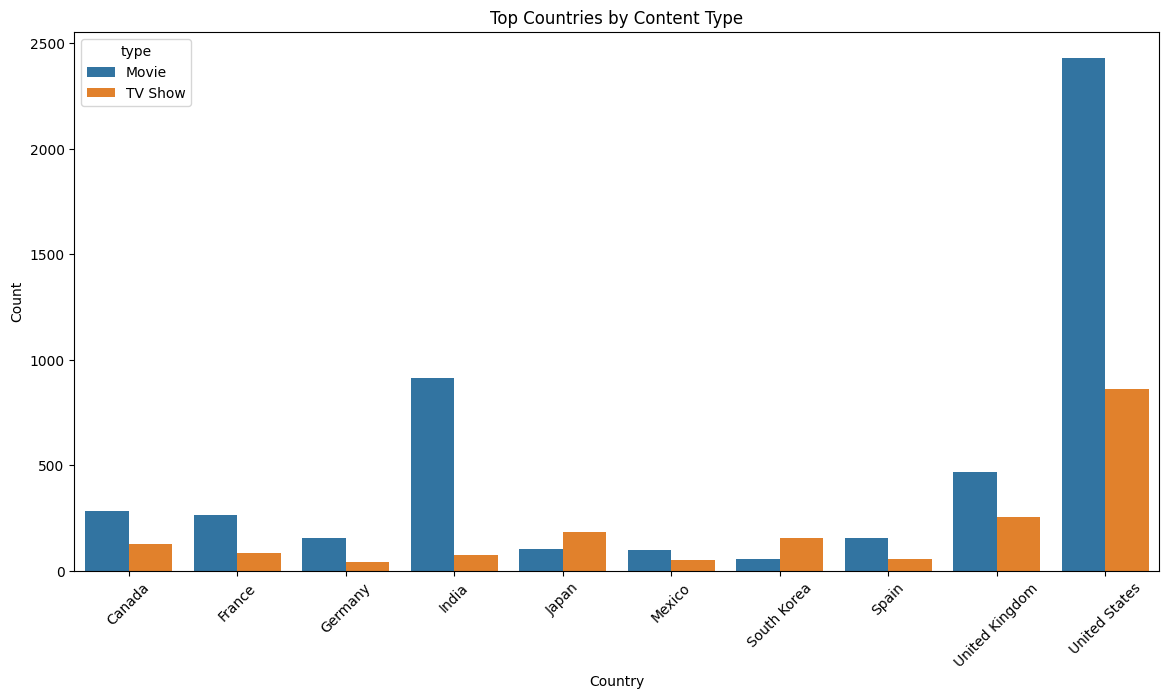

In [ ]:
#Country vs Content Type
country_type = country_df.groupby(['country_list', 'type']).size().reset_index(name='count')

top_country_names = country_df['country_list'].value_counts().head(10).index
country_type_top = country_type[country_type['country_list'].isin(top_country_names)]

plt.figure(figsize=(14,7))
sns.barplot(data=country_type_top, x='country_list', y='count', hue='type')
plt.xticks(rotation=45)
plt.title("Top Countries by Content Type")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

In [34]:
#Separate movie duration and TV show seasons
df['duration_int'] = df['duration'].str.extract(r'(\d+)')
df['duration_int'] = pd.to_numeric(df['duration_int'],errors='coerce')

df['duration_type'] = df['duration'].str.extract(r'([A-Za-z]+)')

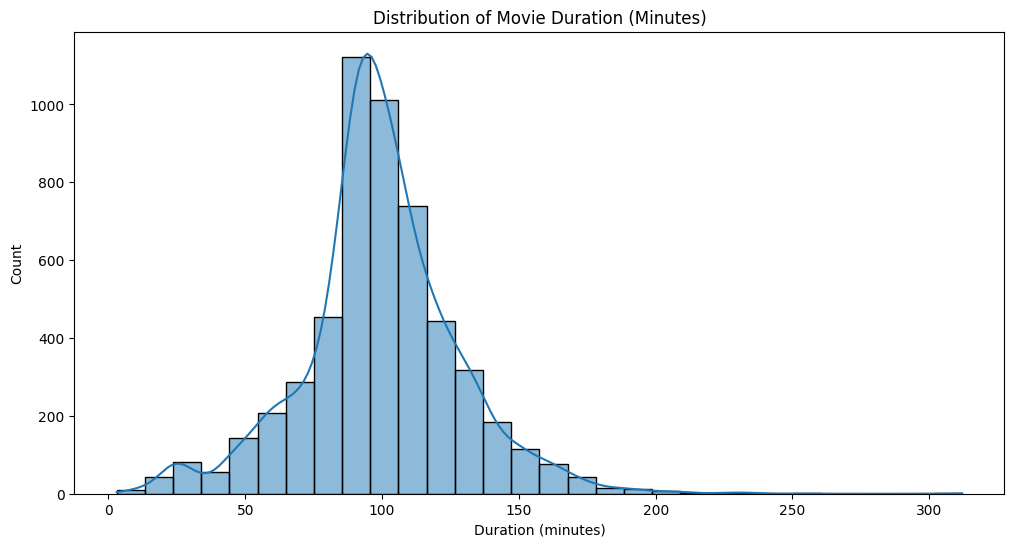

In [ ]:
# Duration--Analysis
# Movie -Duration -Distribution
movie_df = df[df['type'] == 'Movie']

plt.figure(figsize=(12,6))
sns.histplot(movie_df['duration_int'].dropna(), bins=30, kde=True)
plt.title("Distribution of Movie Duration (Minutes)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()

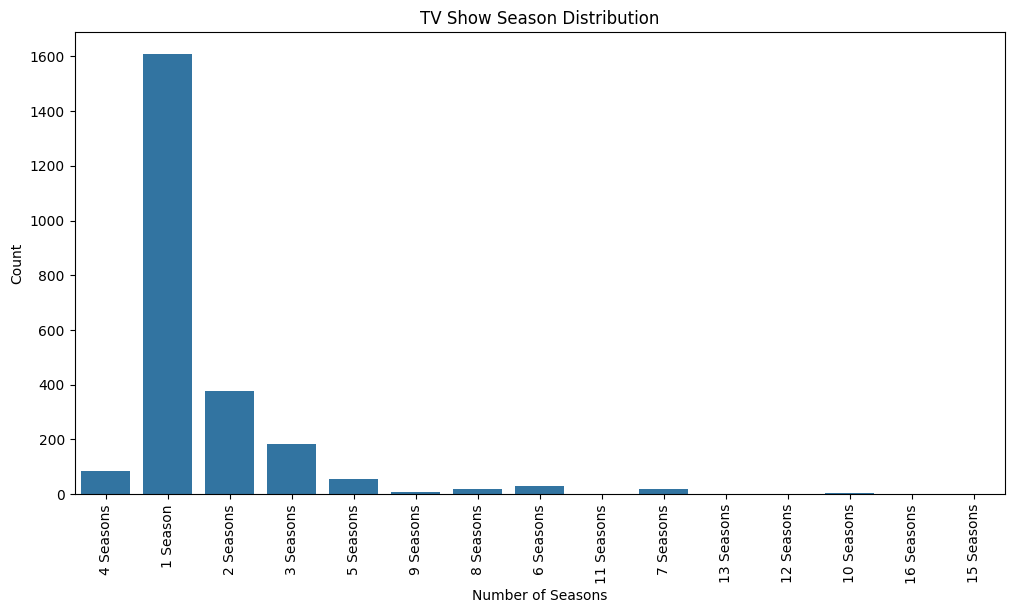

In [ ]:
#Tv show season distribution
tv_df = df[df['type'] == 'TV Show']

plt.figure(figsize=(12,6))
sns.countplot(data=tv_df, x='duration')
plt.xticks(rotation=90)
plt.title("TV Show Season Distribution")
plt.xlabel("Number of Seasons")
plt.ylabel("Count")
plt.show()

In [ ]:
#converting date added to date-time and extracting month
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

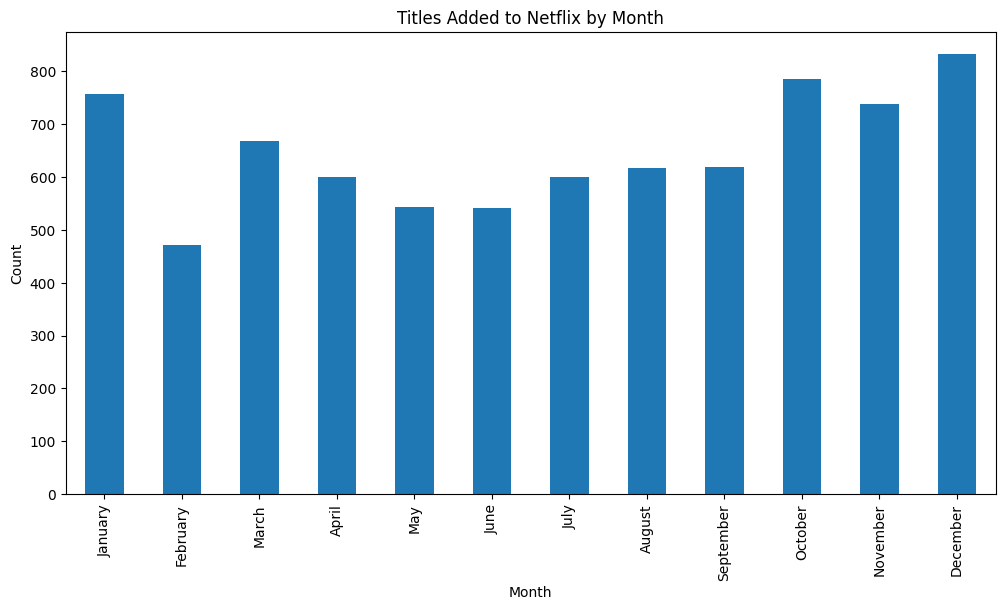

In [ ]:
#Content added by month

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

month_counts = df['month_added'].value_counts().reindex(month_order)

plt.figure(figsize=(12,6))
month_counts.plot(kind='bar')
plt.title("Titles Added to Netflix by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()